## Demo

In [ ]:
#!pip3 install yfinance
# for those who do not have yfinance installed

In [25]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from scipy import stats

from pyconnectedness import dynamic_connectedness, static_connectedness
from pyconnectedness.viz import (
    connectedness_graph,
    plot_connectedness_graph,
    spillover_heatmap,
)

while not os.path.isdir("examples") and os.path.basename(os.getcwd()):
    os.chdir("..")

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

In [26]:
markets = {
    "^AORD": "Australia",
    "^N225": "Japan",
    "^HSI": "Hong Kong",
    "^GDAXI": "Germany",
    "^FCHI": "France",
    "^FTSE": "UK",
    "^GSPTSE": "Canada",
    "^GSPC": "US",
    "^SSMI": "Switzerland",

    "^STI": "Singapore",
    "^JKSE": "Indonesia",
    "^MXX": "Mexico",
    "^BVSP": "Brazil",
    "^IBEX": "Spain",
    "^KLSE": "Malaysia",
    "^MERV": "Argentina",
    "^KS11": "South Korea",
    "XU100.IS": "Turkey",
    "000001.SS": "China",
    "^TWII": "Taiwan",
}

raw = yf.download(
    list(markets),
    start="1997-07-01",
    end="2026-09-01",
    interval="1d",
    auto_adjust=True,
    progress=False,
)

print("Trading days:", len(raw))
print("Sample:", raw.index.min().date(), "->", raw.index.max().date())

Trading days: 7589
Sample: 1997-07-01 -> 2026-08-31


In [27]:
raw

Price             Close                                                                                                                                                                              \
Ticker        000001.SS      XU100.IS        ^AORD     ^BVSP        ^FCHI         ^FTSE        ^GDAXI        ^GSPC       ^GSPTSE          ^HSI         ^IBEX        ^JKSE        ^KLSE        ^KS11   
Date                                                                                                                                                                                                  
1997-07-01          NaN     18.509903  2721.199951   13002.0  2944.000000   4728.299805   3834.840088   891.030029           NaN           NaN   6969.893066   731.590515  1078.900024   758.030029   
1997-07-02  1199.061035     18.729900  2745.899902   13260.0  2909.500000   4751.399902   3867.530029   904.030029   6549.000000           NaN   7094.992676   730.126587  1084.880005   777.289978   
1997-07-03  1150.623047     19.119900  2742.899902   13285.0  2937.000000   4831.700195   3939.729980   916.919983   6588.000000  15055.700195   7174.392578   735.463379  1080.609985   775.260010   
1997-07-04  1159.342041     19.179899  2733.399902   13494.0  2934.500000   4812.799805   3946.729980          NaN   6585.399902  14823.000000   7174.292480   736.568359  1073.310059   781.700012   
1997-07-07  1096.818970     19.529898  2713.000000   13502.0  2947.699951   4810.700195   4003.350098   912.200012   6529.100098  14858.599609   7204.492676   737.977234  1060.530029   773.510010   
...                 ...           ...          ...       ...          ...           ...           ...          ...           ...           ...           ...          ...          ...          ...   
2026-08-25  3889.445068  14473.400391  9374.900391  174577.0  8439.200195  10886.200195  26266.140625  7677.279785  36957.601562  25511.099609  20056.599609          NaN          NaN  6742.740234   
2026-08-26  3912.522949  14610.900391  9338.799805  174586.0  8462.389648  10878.099609  26285.960938  7675.700195  36813.699219  25652.970703  20067.300781  6405.685059  1748.540039  6808.209961   
2026-08-27  3956.571045  14575.500000  9243.200195  175135.0  8319.870117  10792.500000  26367.240234  7730.990234  36834.300781  25565.740234  19881.599609  6521.750000  1741.719971  6912.370117   
2026-08-28  3952.178955  14641.599609  9294.299805  175665.0  8401.179688  10824.299805  26569.990234  7711.759766  36553.898438  25584.789062  20041.900391  6518.121094  1725.880005  6788.879883   
2026-08-31  3986.298096  14334.099609  9271.400391  177419.0  8334.500000           NaN  26258.109375  7686.140137  36270.500000  25566.990234  19974.099609  6525.478027          NaN  6820.020020   

Price                  ...       Volume                                                                                                                                                          \
Ticker          ^MERV  ...        ^FTSE      ^GDAXI         ^GSPC      ^GSPTSE          ^HSI ^IBEX        ^JKSE        ^KLSE     ^KS11 ^MERV         ^MXX        ^N225       ^SSMI         ^STI   
Date                   ...                                                                                                                                                                        
1997-07-01      818.0  ...          0.0         0.0  5.441900e+08          NaN           NaN   0.0    3693300.0          0.0   37000.0   0.0          0.0          0.0         0.0    1043100.0   
1997-07-02      824.0  ...          0.0         0.0  5.269700e+08   54370800.0           NaN   0.0    3457200.0          0.0   52200.0   0.0          0.0          0.0         0.0     569600.0   
1997-07-03      831.0  ...          0.0         0.0  3.746800e+08   54873600.0  0.000000e+00   0.0    2738300.0          0.0   51200.0   0.0          0.0          0.0         0.0     580800.0   
1997-07-04      838.0  ...          0.0    

In [28]:
close = raw["Close"].rename(columns=markets)[list(markets.values())]
high = raw["High"].rename(columns=markets)[list(markets.values())]
low = raw["Low"].rename(columns=markets)[list(markets.values())]

weekly_close = close.resample("W-FRI").last().ffill()
weekly_high = high.resample("W-FRI").max().ffill()
weekly_low = low.resample("W-FRI").min().ffill()

returns = np.log(weekly_close).diff().mul(100)
volatility = 100 * np.sqrt(52 * 0.361 * (np.log(weekly_high) - np.log(weekly_low)) ** 2)

# balanced panel: keep only weeks where every market quotes
sample = returns.dropna().index.intersection(volatility.dropna().index)
returns = returns.loc[sample]
volatility = volatility.loc[sample]

print("Markets:", len(returns.columns))
print("Weeks:", len(returns), "| Missing:", int(returns.isna().sum().sum()))
print("Sample:", returns.index.min().date(), "->", returns.index.max().date())

Markets: 20
Weeks: 1522 | Missing: 0
Sample: 1997-07-11 -> 2026-09-04


In [29]:
returns

Ticker,Australia,Japan,Hong Kong,Germany,France,UK,Canada,US,Switzerland,Singapore,Indonesia,Mexico,Brazil,Spain,Malaysia,Argentina,South Korea,Turkey,China,Taiwan
Date,,,,,,,,,,,,,,,,,,,,
1997-07-11,-1.262780,-0.464367,2.677848,3.181158,0.241660,-0.276725,0.620659,-0.026177,-0.772669,-0.951186,-1.805649,3.740057,-2.559527,-0.865138,-5.329066,1.539403,-1.729078,5.527390,-0.393071,2.174275
1997-07-18,-0.553571,1.863390,2.241320,1.404805,-2.230990,1.605958,1.673120,-0.150657,-1.116263,-2.205009,0.080688,-2.119112,-16.234453,-3.815999,-1.590794,-5.930352,-2.761990,-0.842219,4.658029,2.965500
1997-07-25,0.260446,0.690075,0.561663,5.568185,5.056475,-0.528339,0.622846,2.533992,1.897484,2.909150,-1.944466,0.040240,11.326161,-1.324798,3.888274,4.748305,-1.854191,-6.208722,-3.276194,1.349782
1997-08-01,1.339827,-2.911881,4.502392,-0.725062,0.776911,0.980436,1.038792,0.885514,0.871854,-1.305811,1.636258,7.043180,-2.130659,-0.379638,-3.780498,0.000000,-0.298958,4.350768,1.858668,1.944986
1997-08-08,-0.592037,-1.014603,1.624781,0.122823,-1.759943,2.658606,0.641631,-1.446314,-0.567891,-0.584738,-6.635094,0.159732,-1.066108,0.778481,-7.266284,1.182047,2.772075,3.339457,1.102607,-0.780115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-08-07,3.316394,1.915429,-0.839540,2.657428,2.383801,0.303181,3.226481,3.514674,1.376022,1.234775,2.744611,0.002463,-3.130534,1.967583,0.627050,-6.415952,-5.239636,2.359363,2.773492,2.532969
2026-08-14,-1.406328,4.627202,-2.170730,0.458158,-0.900549,-1.394865,0.954991,0.361821,-1.066104,0.789369,-0.121229,-3.870236,-3.287407,-0.096202,-0.482799,-4.622397,10.877005,2.811459,-0.326929,3.521367
2026-08-21,-0.468173,-4.004743,3.492143,-1.155464,-1.779944,0.616693,-0.300207,-1.441017,0.459730,-0.955698,1.915371,2.046894,2.425215,-0.972634,0.524846,-1.165948,-0.935724,2.387946,-0.561111,-1.289018


In [30]:
pd.DataFrame({
    "Mean": returns.mean(),
    "Median": returns.median(),
    "Maximum": returns.max(),
    "Minimum": returns.min(),
    "Std.Dev.": returns.std(ddof=1),
    "Skewness": pd.Series(stats.skew(returns, bias=True), index=returns.columns),
    "Kurtosis": pd.Series(
        stats.kurtosis(returns, fisher=False, bias=True), index=returns.columns
    ),
}).round(3)

,Mean,Median,Maximum,Minimum,Std.Dev.,Skewness,Kurtosis
Ticker,,,,,,,
Australia,0.080,0.242,8.101,-17.710,2.004,-1.228,10.745
Japan,0.079,0.241,15.817,-27.884,3.002,-0.781,9.608
Hong Kong,0.036,0.226,13.917,-19.922,3.248,-0.344,6.044
Germany,0.125,0.393,14.942,-24.347,3.121,-0.808,8.988
France,0.069,0.248,12.432,-25.050,2.920,-0.958,9.994
UK,0.053,0.208,12.583,-23.632,2.357,-1.154,14.348
Canada,0.112,0.317,12.817,-17.542,2.309,-1.179,11.497
US,0.140,0.271,11.424,-20.084,2.468,-0.810,9.508
Switzerland,0.059,0.267,16.288,-25.202,2.525,-1.151,15.173


In [31]:
volatility.describe().T[["mean", "50%", "min", "max", "std"]].round(1)

,mean,50%,min,max,std
Ticker,,,,,
Australia,11.4,9.5,2.0,104.5,7.5
Japan,16.8,14.9,2.3,125.4,9.8
Hong Kong,18.4,15.6,3.4,139.4,11.7
Germany,18.1,15.2,2.5,114.1,11.7
France,17.1,14.6,2.9,108.1,10.6
UK,14.1,11.8,3.2,108.8,9.3
Canada,12.5,10.1,2.4,89.6,9.1
US,14.0,11.5,1.8,116.0,9.4
Switzerland,14.0,11.4,2.6,102.5,9.8


In [32]:
log_vola = np.log(volatility)

ret_conn = static_connectedness(returns, horizon=10, method="generalized", lags=2)
vol_conn = static_connectedness(log_vola, horizon=10, method="generalized", lags=2)

print("Total RETURN spillover index:    ", round(ret_conn.total, 2), "%")
print("Total VOLATILITY spillover index:", round(vol_conn.total, 2), "%")
ret_conn.table.round(1)

Total RETURN spillover index:     78.34 %
Total VOLATILITY spillover index: 73.74 %


,Australia,Japan,Hong Kong,Germany,France,UK,Canada,US,Switzerland,Singapore,Indonesia,Mexico,Brazil,Spain,Malaysia,Argentina,South Korea,Turkey,China,Taiwan,FROM
Australia,15.3,5.2,4.4,6.2,7.0,7.5,7.6,7.2,5.9,4.8,2.4,4.8,4.0,5.5,1.7,2.1,3.6,1.6,0.4,2.9,84.7
Japan,6.4,18.6,4.5,6.5,6.8,6.0,5.5,6.4,5.4,5.0,2.3,3.5,3.3,5.2,1.7,1.7,4.9,1.5,0.6,4.2,81.4
Hong Kong,5.2,4.4,18.2,5.4,5.7,6.1,4.7,4.9,4.1,8.6,3.0,4.7,3.8,4.3,2.9,1.9,4.6,1.3,1.7,4.4,81.8
Germany,4.9,4.3,3.7,12.8,10.8,8.8,6.2,7.5,8.1,3.8,1.6,4.5,3.9,8.6,1.1,2.0,2.9,1.8,0.4,2.4,87.2
France,5.4,4.4,3.7,10.4,12.4,9.4,6.5,7.3,8.1,3.7,1.6,4.3,3.8,9.1,1.1,1.9,2.7,1.6,0.3,2.3,87.6
UK,6.0,4.1,4.2,8.8,9.7,12.9,6.8,7.5,8.2,4.1,1.5,4.6,3.9,7.6,1.1,2.3,2.7,1.8,0.3,2.1,87.1
Canada,7.0,4.2,3.6,6.9,7.5,7.6,14.4,9.0,5.7,4.3,2.2,5.2,4.9,6.0,1.7,2.5,3.1,1.5,0.4,2.6,85.6
US,6.2,4.5,3.5,8.0,8.1,8.0,8.6,13.9,6.7,3.8,1.5,5.7,4.4,6.3,1.1,2.4,2.9,1.4,0.3,2.5,86.1
Switzerland,5.7,4.3,3.4,9.5,9.9,9.7,6.0,7.5,15.4,3.7,1.6,3.7,3.2,8.0,0.9,1.6,2.2,1.4,0.3,2.0,84.6
Singapore,5.3,4.7,8.0,5.2,5.4,5.9,5.4,5.2,4.3,16.8,4.1,4.5,3.5,4.5,4.4,2.2,4.5,1.3,0.5,4.2,83.2


In [33]:
vol_conn.table.round(1)

,Australia,Japan,Hong Kong,Germany,France,UK,Canada,US,Switzerland,Singapore,Indonesia,Mexico,Brazil,Spain,Malaysia,Argentina,South Korea,Turkey,China,Taiwan,FROM
Australia,21.9,3.1,4.4,5.7,7.0,8.6,8.2,7.2,6.6,3.9,1.6,3.9,2.3,5.7,1.7,1.5,2.4,0.4,1.4,2.4,78.1
Japan,4.4,25.3,3.6,6.1,6.5,5.8,4.5,5.5,6.7,4.3,2.4,3.0,2.4,4.8,1.3,1.4,5.0,1.9,0.8,4.4,74.7
Hong Kong,4.2,2.4,23.6,4.6,4.9,5.7,4.5,5.6,4.4,7.4,2.6,3.9,2.4,3.1,4.6,1.6,5.8,2.3,1.7,4.8,76.4
Germany,3.6,2.6,2.8,16.6,12.6,9.3,5.0,7.8,9.4,3.5,1.3,2.8,3.2,8.3,1.4,0.9,3.3,1.7,0.6,3.1,83.4
France,4.3,2.6,3.0,12.2,16.0,10.2,5.5,7.6,9.0,3.4,1.2,2.6,2.6,9.7,1.2,0.8,2.8,1.4,0.7,3.0,84.0
UK,5.3,2.3,3.4,9.0,10.3,16.4,5.9,7.6,8.5,4.1,1.6,3.5,2.8,7.8,1.8,1.1,3.4,1.5,0.8,2.9,83.6
Canada,6.5,2.3,3.7,6.5,7.6,7.7,19.5,9.7,5.2,3.7,1.5,4.5,3.4,5.5,1.4,1.3,3.2,1.6,1.2,4.0,80.5
US,4.9,2.6,3.9,8.2,8.4,8.9,8.5,16.9,7.4,3.3,1.5,4.0,2.7,5.7,1.6,1.5,3.7,1.5,0.7,3.8,83.1
Switzerland,4.8,3.2,3.1,10.3,10.4,9.9,4.5,7.4,17.8,3.8,1.7,3.0,2.6,6.8,1.7,1.0,3.0,1.4,1.0,2.6,82.2
Singapore,3.8,2.6,6.1,5.4,5.6,6.9,4.5,4.7,5.4,19.3,3.7,4.0,3.5,3.9,5.4,1.0,5.6,2.6,1.4,4.6,80.7


In [34]:
pd.Series({
    "volatility in levels (DY-2009)": static_connectedness(
        volatility, horizon=10, method="generalized", lags=2
    ).total,
    "log volatility (DY-2012/2014)": vol_conn.total,
}, name="TCI %").round(2)

volatility in levels (DY-2009)    77.05
log volatility (DY-2012/2014)     73.74
Name: TCI %, dtype: float64

In [35]:
ret_dyn = dynamic_connectedness(returns, window=200, horizon=10, method="generalized", lags=2)
vol_dyn = dynamic_connectedness(log_vola, window=200, horizon=10, method="generalized", lags=2)

print("Windows:", ret_dyn.n_windows, "| First:", ret_dyn.total.index[0].date())

Windows: 1323 | First: 2001-05-04


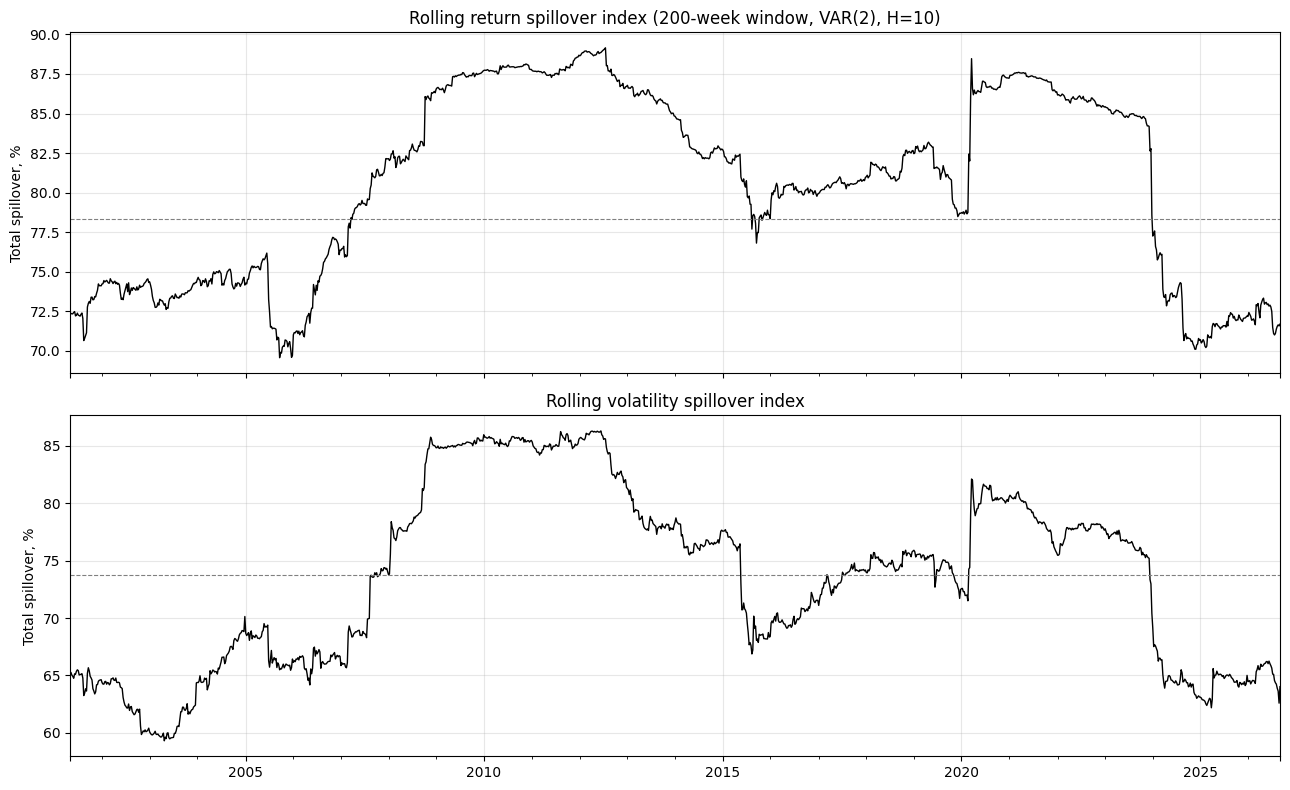

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

ret_dyn.total.plot(ax=axes[0], color="black", lw=1)
axes[0].axhline(ret_conn.total, color="grey", ls="--", lw=0.8)
axes[0].set_title("Rolling return spillover index (200-week window, VAR(2), H=10)")
axes[0].set_ylabel("Total spillover, %")
axes[0].grid(alpha=0.3)

vol_dyn.total.plot(ax=axes[1], color="black", lw=1)
axes[1].axhline(vol_conn.total, color="grey", ls="--", lw=0.8)
axes[1].set_title("Rolling volatility spillover index")
axes[1].set_ylabel("Total spillover, %")
axes[1].set_xlabel("")
axes[1].grid(alpha=0.3)



plt.tight_layout()
plt.show()

In [37]:
episodes = pd.DatetimeIndex([
    "2001-09-30",  # dot-com bust
    "2008-10-31",  # Lehman
    "2011-09-30",  # euro-area crisis
    "2015-08-31",  # China devaluation
    "2020-03-31",  # COVID crash
    "2022-09-30",  # inflation shock
])

pd.DataFrame({
    "Return spillover": ret_dyn.total.reindex(episodes, method="ffill"),
    "Volatility spillover": vol_dyn.total.reindex(episodes, method="ffill"),
}).round(1)

,Return spillover,Volatility spillover
2001-09-30,73.1,65.4
2008-10-31,86.1,84.7
2011-09-30,87.9,86.1
2015-08-31,78.6,70.2
2020-03-31,86.6,82.0
2022-09-30,86.0,78.2


In [38]:
pd.DataFrame({
    "TO": ret_conn.directional_to,
    "FROM": ret_conn.directional_from,
    "NET": ret_conn.net,
}).sort_values("NET", ascending=False).round(1)

,TO,FROM,NET
France,122.4,87.6,34.8
UK,119.5,87.1,32.4
Germany,118.4,87.2,31.2
US,110.8,86.1,24.7
Canada,106.9,85.6,21.3
Spain,102.3,85.6,16.6
Australia,96.0,84.7,11.3
Switzerland,93.8,84.6,9.2
Singapore,89.3,83.2,6.1
Hong Kong,84.2,81.8,2.3


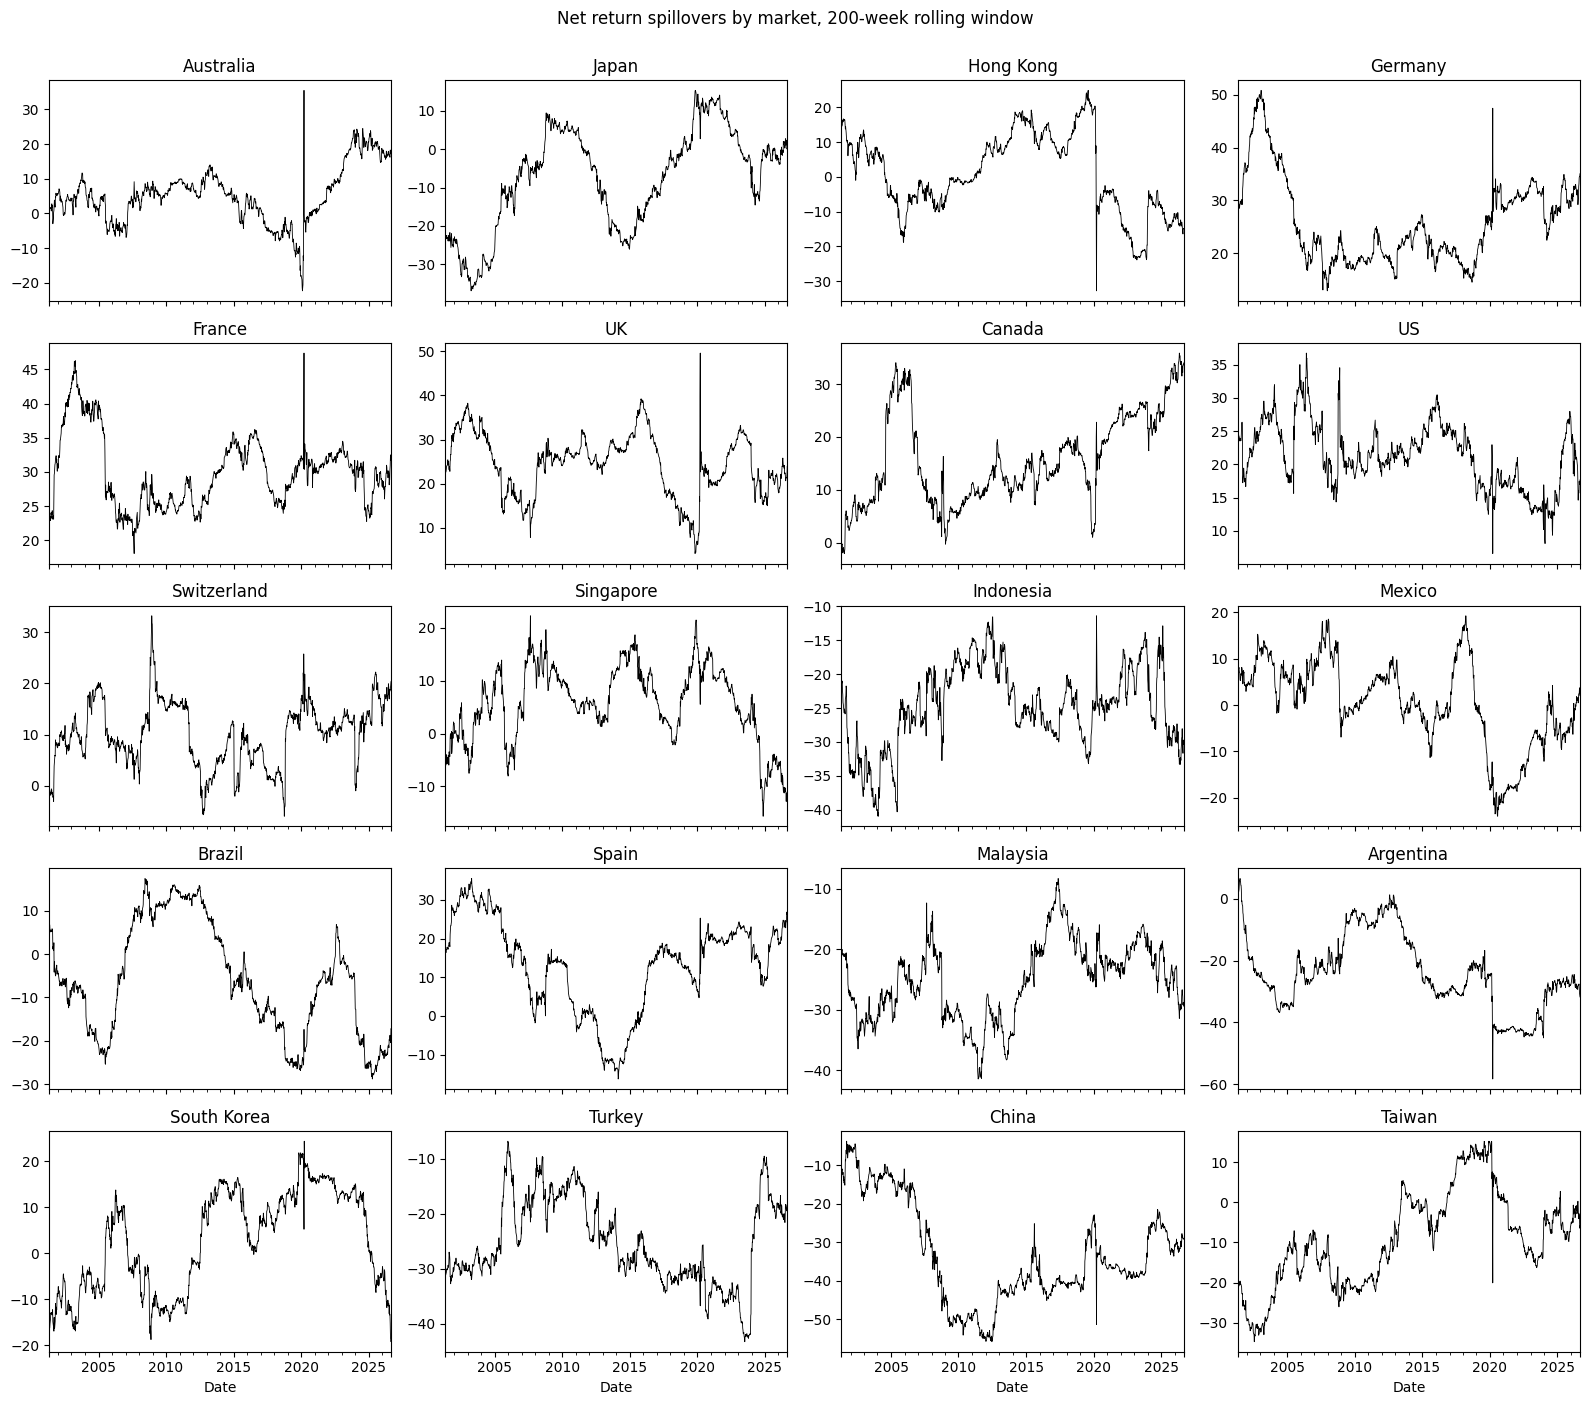

In [39]:
fig, axes = plt.subplots(5, 4, figsize=(16, 14), sharex=True)
ret_dyn.net.plot(
    subplots=True,
    ax=axes.ravel(),
    legend=False,
    color="black",
    lw=0.6,
    title=list(ret_dyn.net.columns),
)
fig.suptitle("Net return spillovers by market, 200-week rolling window", y=1.0)
plt.tight_layout()
plt.show()

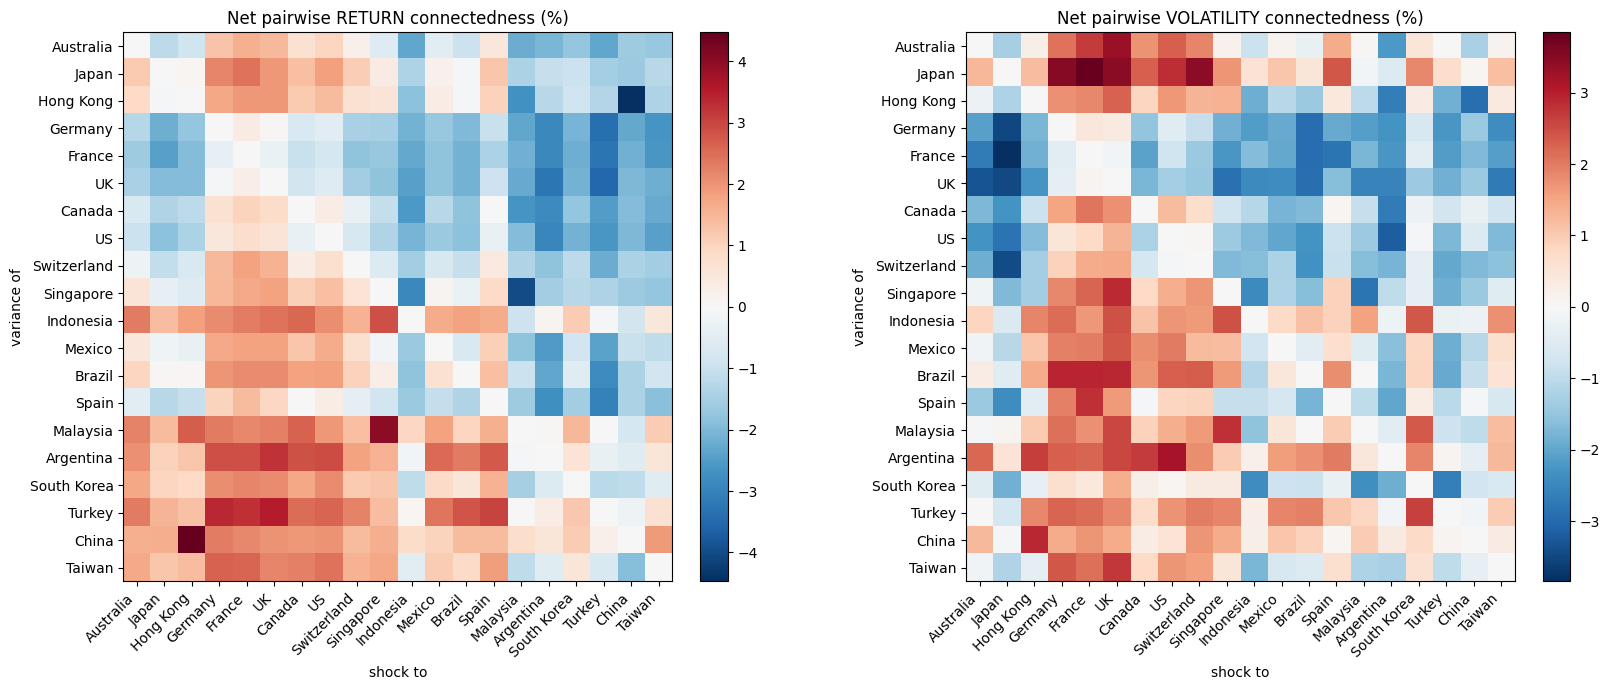

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
spillover_heatmap(ret_conn.pairwise_net, ax=axes[0], cmap="RdBu_r", annotate=False)
axes[0].set_title("Net pairwise RETURN connectedness (%)")
spillover_heatmap(vol_conn.pairwise_net, ax=axes[1], cmap="RdBu_r", annotate=False)
axes[1].set_title("Net pairwise VOLATILITY connectedness (%)")
plt.tight_layout()
plt.show()
# pairwise

Threshold: 2.54 % | edges: 20


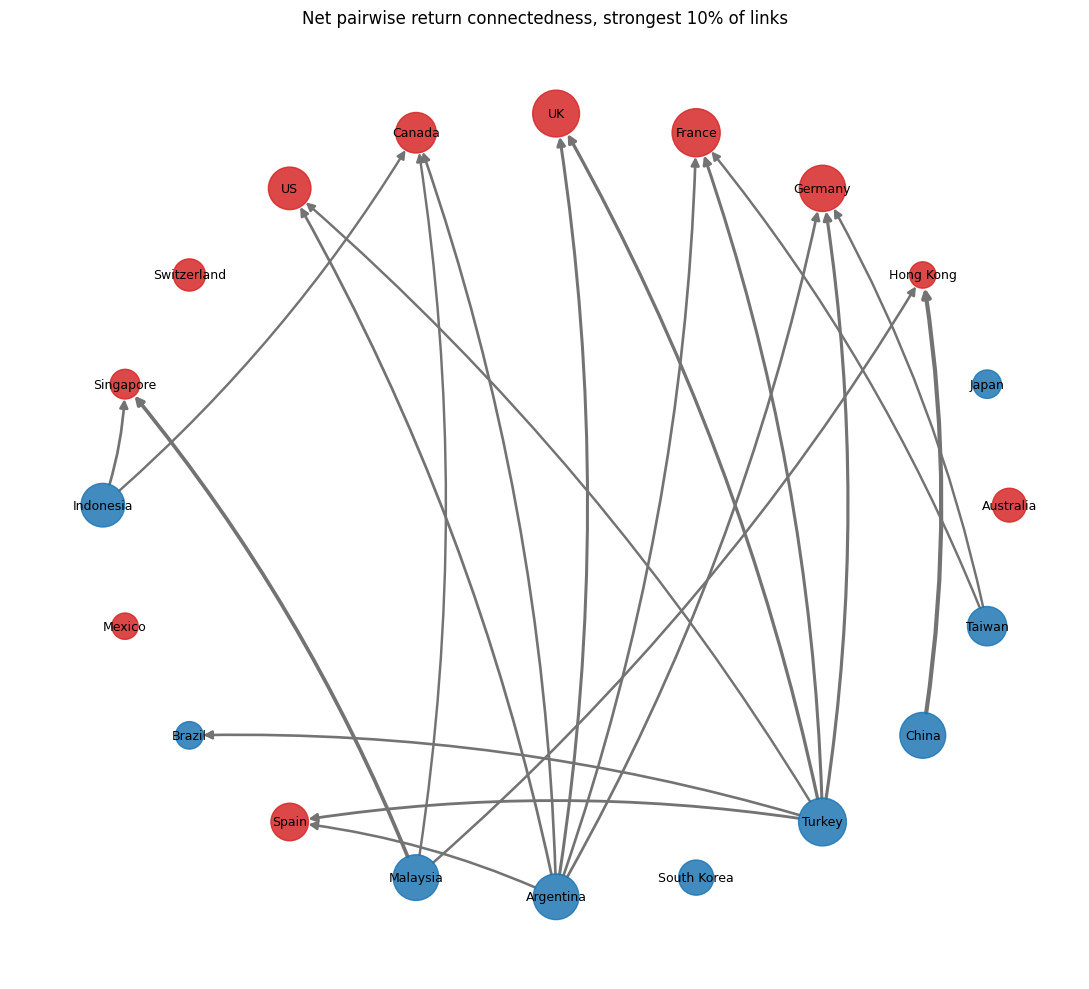

In [41]:
threshold = np.percentile(np.abs(ret_conn.pairwise_net.to_numpy()), 90)
graph = connectedness_graph(ret_conn, threshold=threshold)
print("Threshold:", round(threshold, 2), "% | edges:", graph.number_of_edges())

fig, ax = plt.subplots(figsize=(11, 10))
plot_connectedness_graph(graph, ax=ax, node_scale=1200, edge_scale=3)
ax.set_title("Net pairwise return connectedness, strongest 10% of links")
plt.tight_layout()
plt.show()

In [42]:
links = ret_conn.pairwise_net.stack()
links[links > 0].sort_values(ascending=False).head(15).round(2).to_frame("Net flow, %")

Net flow, %
China     Hong Kong         4.47
Malaysia  Singapore         3.99
Turkey    UK                3.50
          Germany           3.38
          France            3.27
Argentina UK                3.25
Turkey    Spain             3.03
Argentina US                2.93
Indonesia Singapore         2.90
Argentina Germany           2.88
          France            2.86
          Canada            2.84
Turkey    Brazil            2.81
Argentina Spain             2.74
Malaysia  Hong Kong         2.71

Window: 2022-11-11 -> 2026-09-04
Total return spillover index: 71.68 %


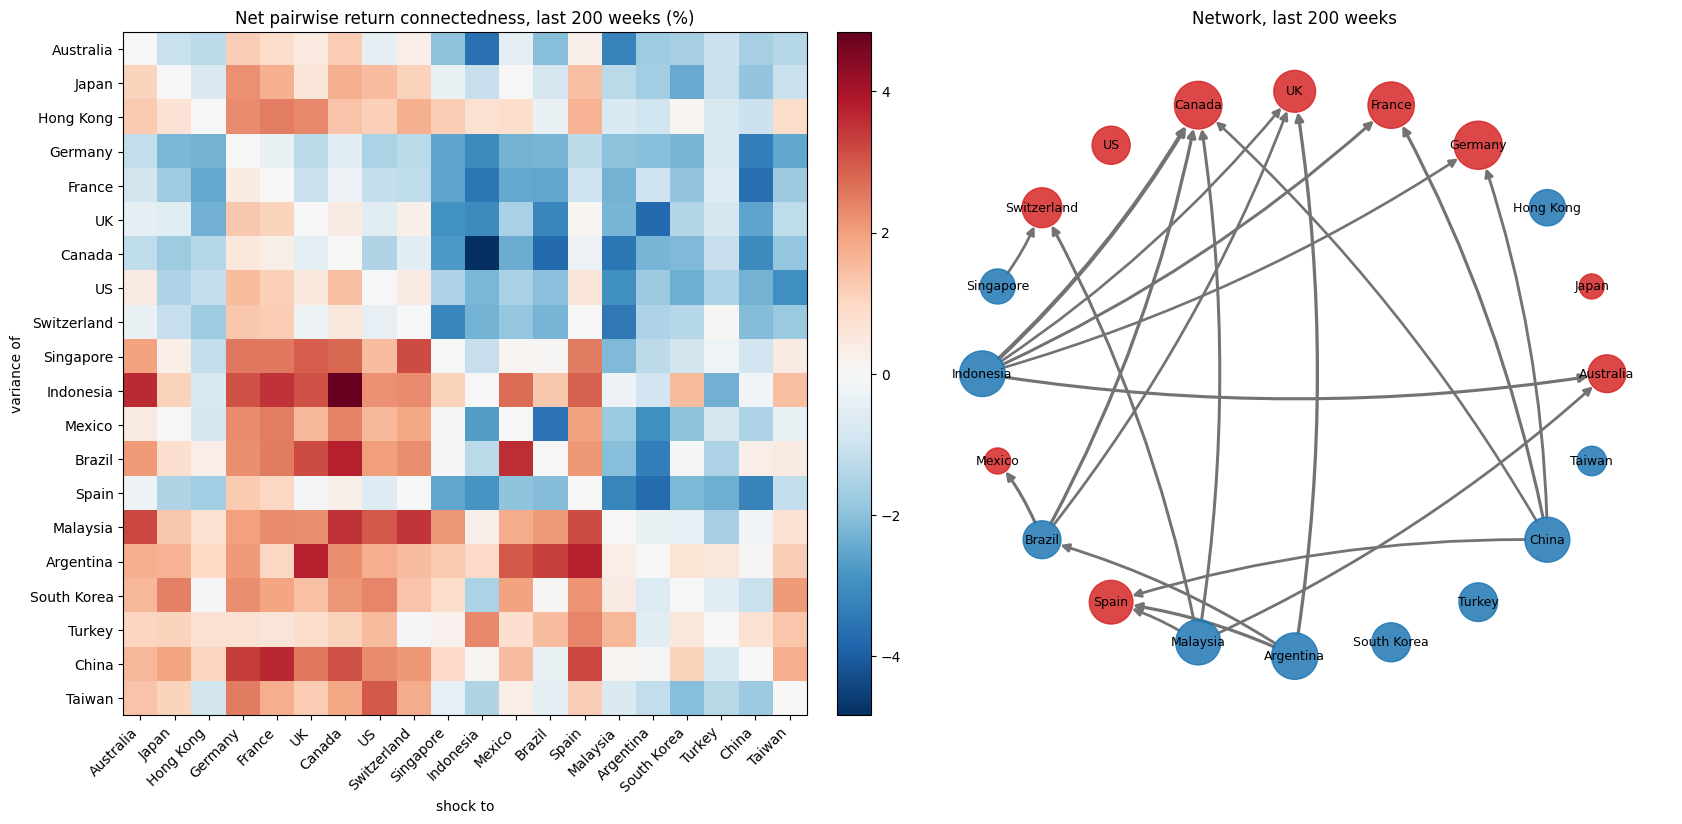

In [43]:
# now on avh

recent = static_connectedness(returns.iloc[-200:], horizon=10, method="generalized", lags=2)
print("Window:", returns.index[-200].date(), "->", returns.index[-1].date())
print("Total return spillover index:", round(recent.total, 2), "%")

fig, axes = plt.subplots(1, 2, figsize=(17, 8))
spillover_heatmap(recent.pairwise_net, ax=axes[0], cmap="RdBu_r", annotate=False)
axes[0].set_title("Net pairwise return connectedness, last 200 weeks (%)")
plot_connectedness_graph(
    connectedness_graph(recent, threshold=np.percentile(np.abs(recent.pairwise_net.to_numpy()), 90)),
    ax=axes[1], node_scale=1200, edge_scale=3,
)
axes[1].set_title("Network, last 200 weeks")
plt.tight_layout()
plt.show()

In [44]:
pd.DataFrame({
    "Full sample": ret_conn.net,
    "Last 200 weeks": recent.net,
}).sort_values("Last 200 weeks", ascending=False).round(1)

,Full sample,Last 200 weeks
Germany,31.2,35.0
Canada,21.3,34.0
France,34.8,31.7
Spain,16.6,26.8
UK,32.4,23.6
Switzerland,9.2,20.4
US,24.7,17.7
Australia,11.3,17.1
Mexico,2.3,2.0
Japan,-4.6,1.0


In [45]:
zeros = (returns == 0).sum().sort_values(ascending=False)
print(zeros.head(8))

runs = (returns.loc["2020-02":"2020-05"] == 0).sum()
print(runs[runs > 0])

Ticker
China          46
Taiwan         21
Indonesia      16
Argentina      11
Turkey         10
Australia       3
UK              2
South Korea     2
dtype: int64
Series([], dtype: int64)


In [46]:
jump = ret_dyn.total.diff().abs()
print(jump.sort_values(ascending=False).head(8).round(2))

Date
2023-12-29    4.22
2020-03-13    4.11
2020-02-28    3.69
2008-10-10    3.10
2020-03-20    2.35
2005-07-01    2.26
2024-03-22    2.21
2020-03-27    1.88
Name: total, dtype: float64


# split by periods

In [47]:
p1 = static_connectedness(returns.loc["1997":"2006"], horizon=10, method="generalized", lags=2)
p2 = static_connectedness(returns.loc["2007":"2012"], horizon=10, method="generalized", lags=2)
p3 = static_connectedness(returns.loc["2013":"2019"], horizon=10, method="generalized", lags=2)
p4 = static_connectedness(returns.loc["2020":"2026"], horizon=10, method="generalized", lags=2)

pd.DataFrame({
    "weeks": [len(returns.loc["1997":"2006"]), len(returns.loc["2007":"2012"]),
              len(returns.loc["2013":"2019"]), len(returns.loc["2020":"2026"])],
    "TCI %": [p1.total, p2.total, p3.total, p4.total],
}, index=["1997-2006 pre-GFC", "2007-2012 GFC+euro",
          "2013-2019 post-crisis", "2020-2026 COVID+"]).round(1)

,weeks,TCI %
1997-2006 pre-GFC,495,71.8
2007-2012 GFC+euro,313,87.4
2013-2019 post-crisis,365,78.7
2020-2026 COVID+,349,79.6


In [48]:
v1 = static_connectedness(log_vola.loc["1997":"2006"], horizon=10, method="generalized", lags=2)
v2 = static_connectedness(log_vola.loc["2007":"2012"], horizon=10, method="generalized", lags=2)
v3 = static_connectedness(log_vola.loc["2013":"2019"], horizon=10, method="generalized", lags=2)
v4 = static_connectedness(log_vola.loc["2020":"2026"], horizon=10, method="generalized", lags=2)

pd.Series({
    "1997-2006": v1.total, "2007-2012": v2.total,
    "2013-2019": v3.total, "2020-2026": v4.total,
}, name="Volatility TCI %").round(1)

1997-2006    69.2
2007-2012    84.1
2013-2019    70.2
2020-2026    70.8
Name: Volatility TCI %, dtype: float64

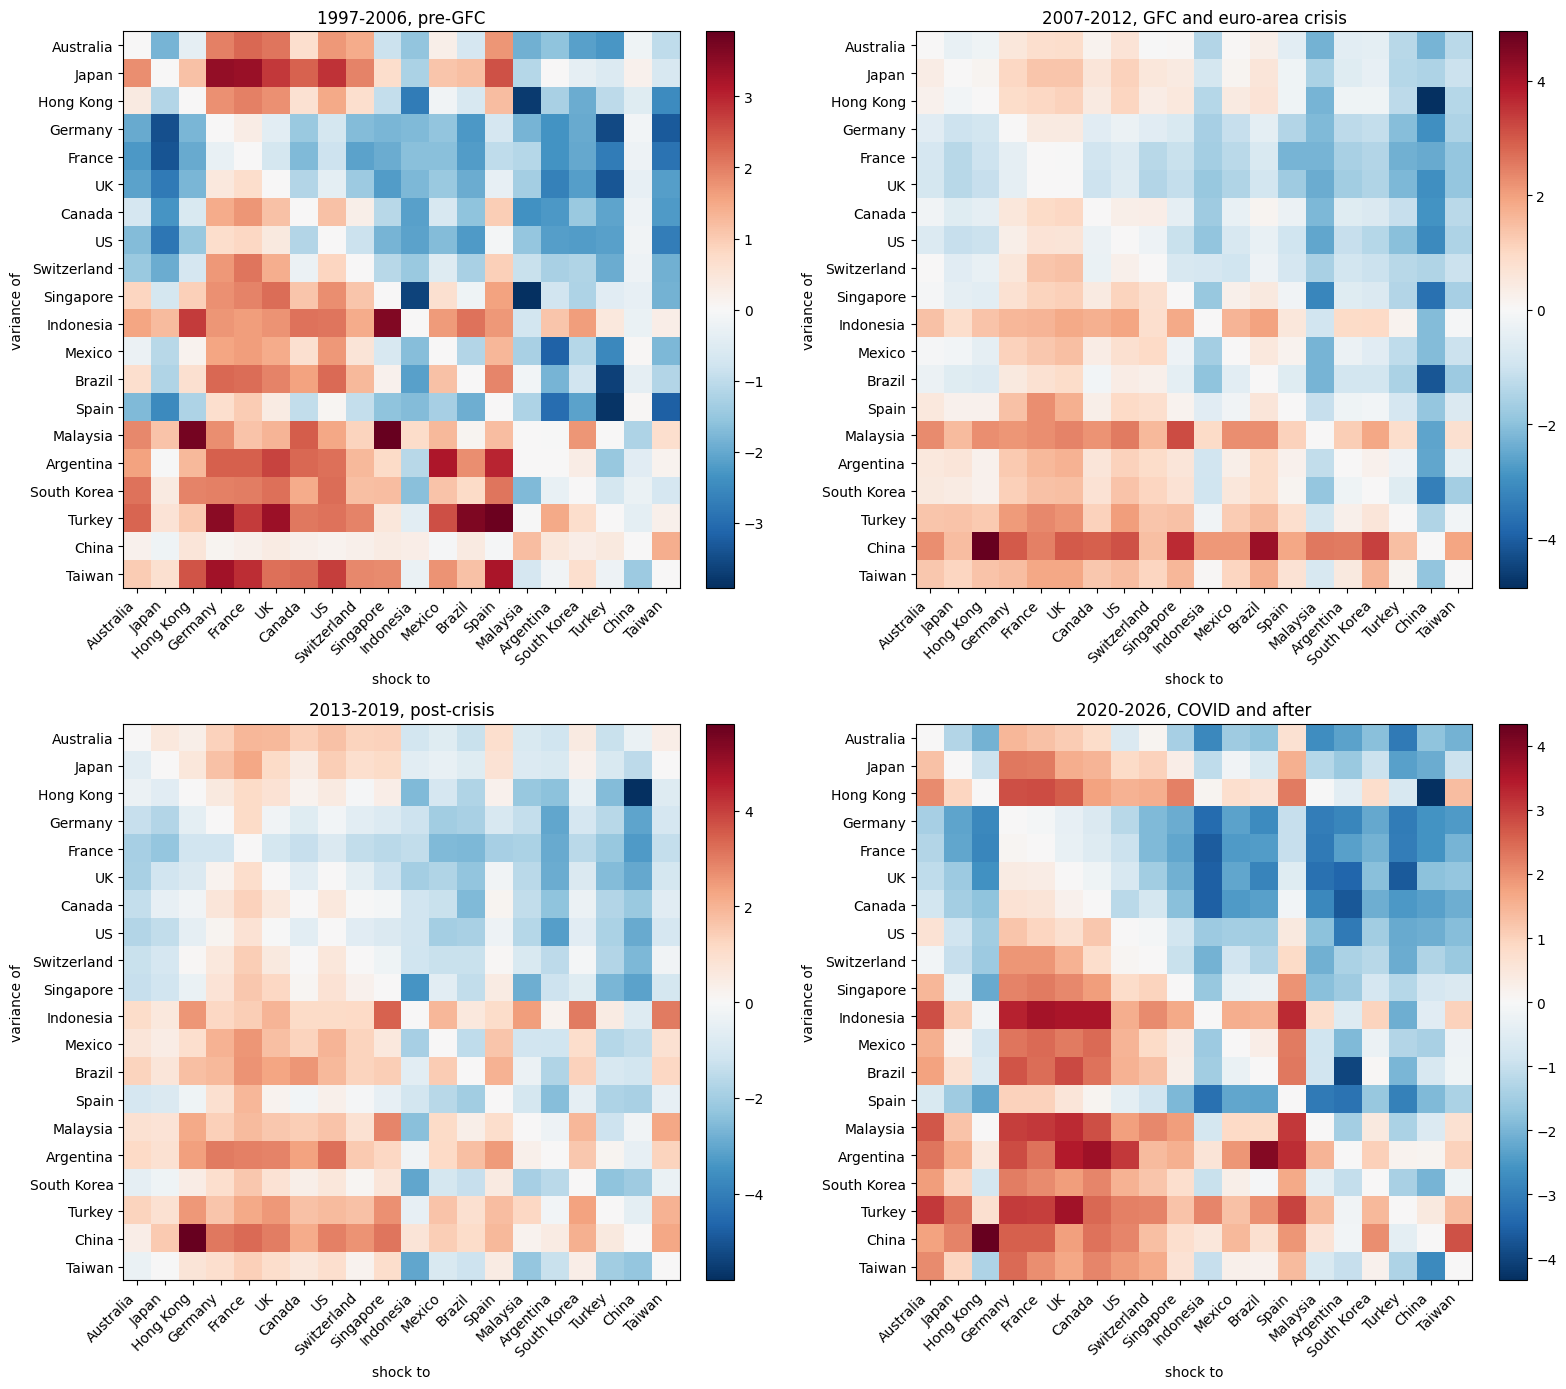

In [49]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
spillover_heatmap(p1.pairwise_net, ax=axes[0, 0], cmap="RdBu_r", annotate=False)
axes[0, 0].set_title("1997-2006, pre-GFC")
spillover_heatmap(p2.pairwise_net, ax=axes[0, 1], cmap="RdBu_r", annotate=False)
axes[0, 1].set_title("2007-2012, GFC and euro-area crisis")
spillover_heatmap(p3.pairwise_net, ax=axes[1, 0], cmap="RdBu_r", annotate=False)
axes[1, 0].set_title("2013-2019, post-crisis")
spillover_heatmap(p4.pairwise_net, ax=axes[1, 1], cmap="RdBu_r", annotate=False)
axes[1, 1].set_title("2020-2026, COVID and after")
plt.tight_layout()
plt.show()

In [53]:
p4.table.round(1)

,Australia,Japan,Hong Kong,Germany,France,UK,Canada,US,Switzerland,Singapore,Indonesia,Mexico,Brazil,Spain,Malaysia,Argentina,South Korea,Turkey,China,Taiwan,FROM
Australia,12.7,4.7,2.1,7.1,6.9,7.3,8.8,7.2,6.2,4.4,2.9,4.8,4.8,6.1,3.2,1.3,3.7,1.2,1.0,3.6,87.3
Japan,6.0,16.3,2.4,7.1,7.0,5.5,6.0,6.3,4.9,4.8,2.3,2.3,2.9,5.7,2.5,0.9,7.3,1.3,1.4,7.1,83.7
Hong Kong,4.2,3.3,24.2,5.2,5.5,5.1,3.4,3.4,4.2,6.3,2.2,3.7,2.6,4.2,3.4,0.4,3.7,0.7,9.0,5.2,75.8
Germany,5.6,4.8,2.4,11.9,10.3,8.7,6.7,6.1,8.1,4.7,2.1,4.1,3.3,8.9,2.3,0.8,3.6,1.0,1.1,3.4,88.1
France,5.6,4.7,2.7,10.4,12.0,8.9,6.4,5.6,8.0,4.7,2.0,4.4,3.3,9.5,2.4,0.7,3.4,1.0,1.2,3.1,88.0
UK,6.2,3.9,2.5,9.0,9.3,12.4,7.2,5.2,7.8,5.0,2.4,4.5,4.2,8.8,2.8,1.2,3.2,1.3,0.7,2.4,87.6
Canada,8.0,4.6,1.6,7.3,7.0,7.4,12.5,8.6,6.2,4.6,2.8,4.9,4.9,6.6,3.3,1.3,3.6,0.9,1.0,3.2,87.5
US,7.8,5.5,1.9,7.3,6.6,5.9,9.7,14.4,5.7,4.0,2.2,4.6,4.0,5.4,2.7,1.3,4.2,1.0,1.3,4.4,85.6
Switzerland,6.1,3.9,2.7,10.0,9.9,9.3,6.9,5.8,15.0,4.0,1.9,3.6,2.4,7.9,2.8,0.7,2.8,0.9,0.9,2.6,85.0
Singapore,5.8,4.6,4.1,6.8,6.9,7.1,6.4,4.8,4.9,15.9,3.0,3.9,3.4,7.1,4.2,0.7,3.9,0.8,0.8,4.9,84.1
